In [1]:
import os

os.environ["KERAS_BACKEND"] = "tensorflow"
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3' # Only errors are logged
os.environ['TF_GPU_ALLOCATOR'] ='cuda_malloc_async'

import numpy as np
import keras
import matplotlib.pyplot as plt
import tensorflow as tf
from keras import layers
from keras import ops

# TF imports related to tf.data preprocessing
from tensorflow import data as tf_data
from tensorflow import image as tf_image
from tensorflow.keras.utils import plot_model

keras.utils.set_random_seed(42)
from sklearn.model_selection import train_test_split

I0000 00:00:1777412598.767852  119427 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1777412599.822141  119427 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
BATCH_SIZE = 32
NUM_CLASSES = 8
EPOCHS = 500
SAMPLE_RATE = 16000
OUT_SEQ_LEN = 72000

In [3]:
keras.backend.clear_session(free_memory=True)
train_ds =tf.keras.utils.image_dataset_from_directory(directory='dataset_stft_img/train',
image_size=(300, 300),
batch_size=BATCH_SIZE)
val_ds =tf.keras.utils.image_dataset_from_directory(directory='dataset_stft_img/val',
image_size=(300, 300),
batch_size=BATCH_SIZE)
test_ds =tf.keras.utils.image_dataset_from_directory(directory='dataset_stft_img/test',
image_size=(300, 300),
batch_size=BATCH_SIZE)

Found 7434 files belonging to 8 classes.
Found 636 files belonging to 8 classes.
Found 636 files belonging to 8 classes.


In [4]:
incv3 = keras.applications.InceptionV3(include_top=False,input_shape=(300,300,3), pooling = 'max')
# incv3.trainable = False
model = keras.Sequential([
  layers.Input(shape=(300,300,3),name='input'),

  incv3,
  layers.Dense((1024),activation='relu'),
  layers.Dense((512),activation='relu'),
  layers.Dense((NUM_CLASSES),activation = 'softmax',name='output')
])
model.summary()
keras.backend.clear_session(free_memory=True)
model.compile(
    optimizer=keras.optimizers.AdamW(learning_rate=1e-4),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=[keras.metrics.SparseCategoricalAccuracy()],
)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ inception_v3 (Functional)       │ (None, 2048)           │    21,802,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1024)           │     2,098,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 8)              │         4,104 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,429,864 (93.19 MB)

 Trainable params: 24,395,432 (93.06 MB)

 Non-trainable params: 34,432 (134.50 KB)

In [5]:
history = model.fit(train_ds,
        batch_size=BATCH_SIZE,
        epochs=EPOCHS,
          validation_data=val_ds,
        callbacks=[
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=5,
            restore_best_weights=True,
        )]        )

Epoch 1/500
233/233 ━━━━━━━━━━━━━━━━━━━━ 100s 226ms/step - loss: 0.9085 - sparse_categorical_accuracy: 0.6772 - val_loss: 0.5333 - val_sparse_categorical_accuracy: 0.7925
Epoch 2/500
233/233 ━━━━━━━━━━━━━━━━━━━━ 18s 76ms/step - loss: 0.4334 - sparse_categorical_accuracy: 0.8407 - val_loss: 0.5116 - val_sparse_categorical_accuracy: 0.8255
Epoch 3/500
233/233 ━━━━━━━━━━━━━━━━━━━━ 18s 75ms/step - loss: 0.3021 - sparse_categorical_accuracy: 0.8900 - val_loss: 0.6930 - val_sparse_categorical_accuracy: 0.7972
Epoch 4/500
233/233 ━━━━━━━━━━━━━━━━━━━━ 18s 76ms/step - loss: 0.1982 - sparse_categorical_accuracy: 0.9317 - val_loss: 0.4124 - val_sparse_categorical_accuracy: 0.8632
Epoch 5/500
233/233 ━━━━━━━━━━━━━━━━━━━━ 18s 76ms/step - loss: 0.1192 - sparse_categorical_accuracy: 0.9587 - val_loss: 0.5700 - val_sparse_categorical_accuracy: 0.8789
Epoch 6/500
233/233 ━━━━━━━━━━━━━━━━━━━━ 18s 76ms/step - loss: 0.1007 - sparse_categorical_accuracy: 0.9680 - val_loss: 0.5183 - val_sparse_categorical_a

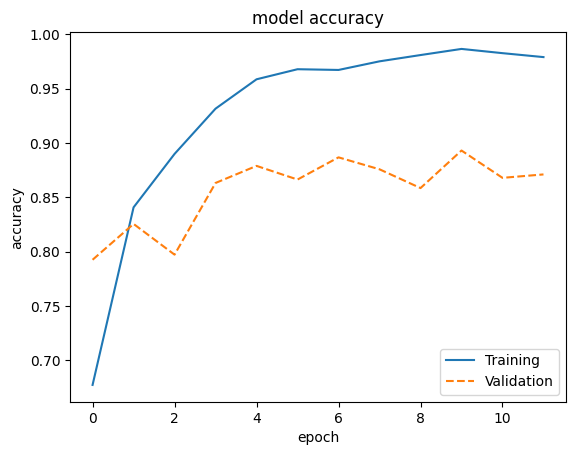

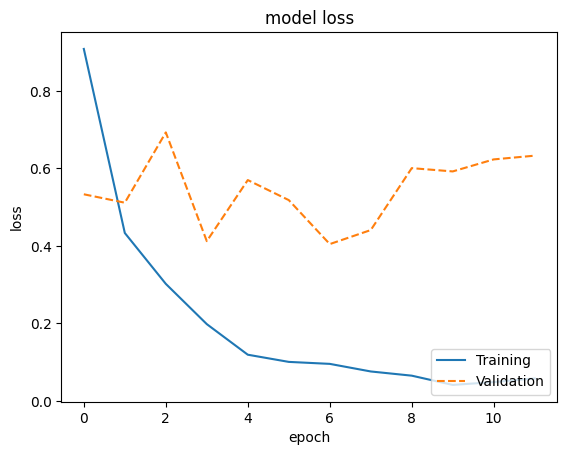

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.4787 - sparse_categorical_accuracy: 0.8569


[0.47871461510658264, 0.856918215751648]

In [6]:
plt.plot(history.history['sparse_categorical_accuracy'])
plt.plot(history.history['val_sparse_categorical_accuracy'],linestyle='--')
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['Training', 'Validation'], loc='lower right')
plt.show()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'],linestyle='--')
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['Training', 'Validation'], loc='lower right')
plt.show()
model.evaluate(test_ds)

In [7]:
incv3_2 = keras.applications.InceptionV3(include_top=False,input_shape=(300,300,3), pooling='max')
incv3_2.trainable = False
model_2 = keras.Sequential([
  layers.Input(shape=(300,300,3),name='input'),
  incv3_2,
  layers.Dropout(0.3),
  # layers.GlobalAveragePooling2D(),
  # layers.BatchNormalization(),
  layers.Dense((512),activation='relu'),
  layers.Dense((NUM_CLASSES),activation = 'softmax',name='output')
])
model_2.summary()
keras.backend.clear_session(free_memory=True)
model_2.compile(
    optimizer=keras.optimizers.AdamW(learning_rate=1e-4),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=[keras.metrics.SparseCategoricalAccuracy()],
)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ inception_v3 (Functional)       │ (None, 2048)           │    21,802,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 8)              │         4,104 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,855,976 (87.19 MB)

 Trainable params: 1,053,192 (4.02 MB)

 Non-trainable params: 21,802,784 (83.17 MB)

In [8]:
history_2 = model_2.fit(train_ds,
        batch_size=BATCH_SIZE,
        epochs=EPOCHS,
          validation_data=val_ds,
        callbacks=[
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=5,
            restore_best_weights=True,
        )]        )

Epoch 1/500
233/233 ━━━━━━━━━━━━━━━━━━━━ 21s 62ms/step - loss: 34.6719 - sparse_categorical_accuracy: 0.3082 - val_loss: 9.2635 - val_sparse_categorical_accuracy: 0.5330
Epoch 2/500
233/233 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 17.0090 - sparse_categorical_accuracy: 0.4149 - val_loss: 5.7727 - val_sparse_categorical_accuracy: 0.6462
Epoch 3/500
233/233 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 12.5152 - sparse_categorical_accuracy: 0.4458 - val_loss: 3.7953 - val_sparse_categorical_accuracy: 0.6384
Epoch 4/500
233/233 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 9.1803 - sparse_categorical_accuracy: 0.4708 - val_loss: 3.1733 - val_sparse_categorical_accuracy: 0.6179
Epoch 5/500
233/233 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 6.8581 - sparse_categorical_accuracy: 0.4426 - val_loss: 2.6621 - val_sparse_categorical_accuracy: 0.5016
Epoch 6/500
233/233 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 4.8692 - sparse_categorical_accuracy: 0.4085 - val_loss: 2.2665 - val_sparse_categorical_accur

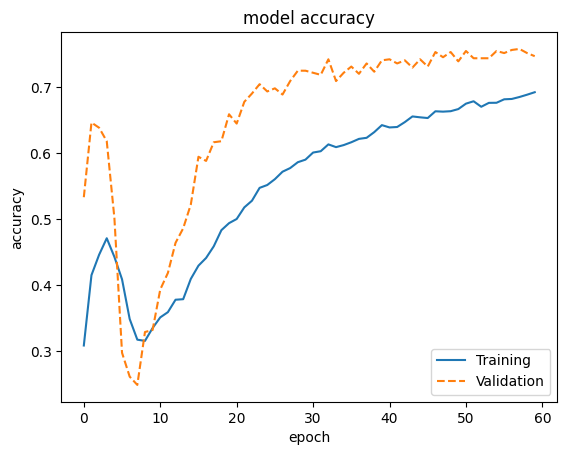

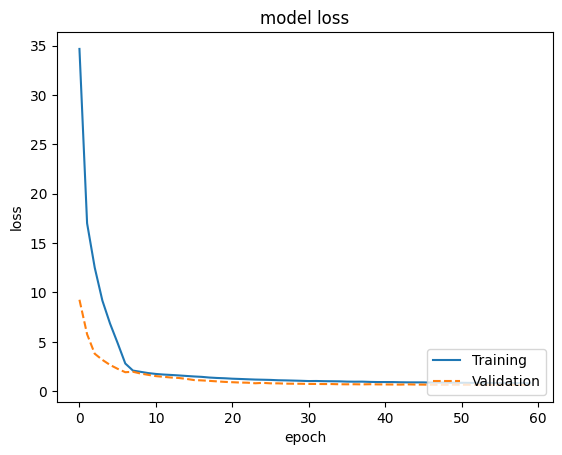

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.6724 - sparse_categorical_accuracy: 0.7531


[0.6724005341529846, 0.7531446814537048]

In [9]:
plt.plot(history_2.history['sparse_categorical_accuracy'])
plt.plot(history_2.history['val_sparse_categorical_accuracy'],linestyle='--')
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['Training', 'Validation'], loc='lower right')
plt.show()
plt.plot(history_2.history['loss'])
plt.plot(history_2.history['val_loss'],linestyle='--')
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['Training', 'Validation'], loc='lower right')
plt.show()
model_2.evaluate(test_ds)

In [10]:
incv3_3 = keras.applications.InceptionV3(include_top=False,input_shape=(300,300,3))
incv3_3.trainable = False
model_3 = keras.Sequential([
  layers.Input(shape=(300,300,3),name='input'),
  incv3_3,
  layers.GlobalAveragePooling2D(),
  layers.BatchNormalization(),
  layers.Dense((128),activation='relu'),
  layers.Dropout(0.3),
  layers.Dense((NUM_CLASSES),activation = 'softmax',name='output')
])
model_3.summary()
keras.backend.clear_session(free_memory=True)
model_3.compile(
    optimizer=keras.optimizers.AdamW(learning_rate=1e-4),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=[keras.metrics.SparseCategoricalAccuracy()],
)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ inception_v3 (Functional)       │ (None, 8, 8, 2048)     │    21,802,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_94          │ (None, 2048)           │         8,192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,074,280 (84.21 MB)

 Trainable params: 267,400 (1.02 MB)

 Non-trainable params: 21,806,880 (83.19 MB)

In [11]:
history_3 = model_3.fit(train_ds,
        batch_size=BATCH_SIZE,
        epochs=EPOCHS,
          validation_data=val_ds,
        callbacks=[
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=5,
            restore_best_weights=True,
        )]        )

Epoch 1/500
233/233 ━━━━━━━━━━━━━━━━━━━━ 22s 65ms/step - loss: 1.5976 - sparse_categorical_accuracy: 0.4416 - val_loss: 0.9002 - val_sparse_categorical_accuracy: 0.7028
Epoch 2/500
233/233 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 1.0885 - sparse_categorical_accuracy: 0.6129 - val_loss: 0.7512 - val_sparse_categorical_accuracy: 0.7484
Epoch 3/500
233/233 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 0.9592 - sparse_categorical_accuracy: 0.6501 - val_loss: 0.6909 - val_sparse_categorical_accuracy: 0.7563
Epoch 4/500
233/233 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 0.8717 - sparse_categorical_accuracy: 0.6827 - val_loss: 0.6679 - val_sparse_categorical_accuracy: 0.7594
Epoch 5/500
233/233 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 0.8079 - sparse_categorical_accuracy: 0.7055 - val_loss: 0.6386 - val_sparse_categorical_accuracy: 0.7720
Epoch 6/500
233/233 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 0.7727 - sparse_categorical_accuracy: 0.7209 - val_loss: 0.6173 - val_sparse_categorical_accuracy

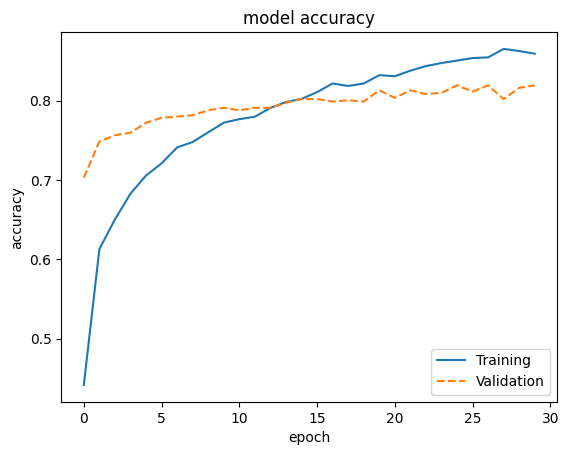

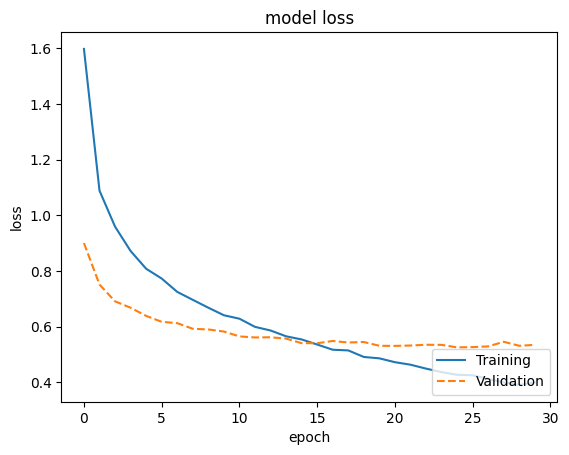

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.5693 - sparse_categorical_accuracy: 0.7940


[0.5693397521972656, 0.794025182723999]

In [12]:
plt.plot(history_3.history['sparse_categorical_accuracy'])
plt.plot(history_3.history['val_sparse_categorical_accuracy'],linestyle='--')
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['Training', 'Validation'], loc='lower right')
plt.show()
plt.plot(history_3.history['loss'])
plt.plot(history_3.history['val_loss'],linestyle='--')
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['Training', 'Validation'], loc='lower right')
plt.show()
model_3.evaluate(test_ds)

In [13]:
incv3_4 = keras.applications.InceptionV3(include_top=False,input_shape=(300,300,3))
incv3_4.trainable = False
# for layer in incv3_4.layers[-50:]:
#     layer.trainable = True
model_4 = keras.Sequential([
  layers.Input(shape=(300,300,3),name='input'),
  layers.Rescaling(1./127.5, offset=-1),
  incv3_4,
  layers.GlobalAveragePooling2D(),
  layers.BatchNormalization(),
  layers.Dense((128),activation='relu'),
  layers.Dropout(0.3),
  layers.Dense((NUM_CLASSES),activation = 'softmax',name='output')
])
model_4.summary()
keras.backend.clear_session(free_memory=True)
model_4.compile(
    optimizer=keras.optimizers.AdamW(learning_rate=1e-5),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=[keras.metrics.SparseCategoricalAccuracy()],
)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 300, 300, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ inception_v3 (Functional)       │ (None, 8, 8, 2048)     │    21,802,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_94          │ (None, 2048)           │         8,192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,074,280 (84.21 MB)

 Trainable params: 267,400 (1.02 MB)

 Non-trainable params: 21,806,880 (83.19 MB)

In [14]:
history_4 = model_4.fit(train_ds,
        batch_size=BATCH_SIZE,
        epochs=EPOCHS,
          validation_data=val_ds,
        callbacks=[
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=5,
            restore_best_weights=True,
        )]        )

Epoch 1/500
233/233 ━━━━━━━━━━━━━━━━━━━━ 20s 60ms/step - loss: 2.4170 - sparse_categorical_accuracy: 0.2031 - val_loss: 1.7139 - val_sparse_categorical_accuracy: 0.4057
Epoch 2/500
233/233 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 1.8905 - sparse_categorical_accuracy: 0.3427 - val_loss: 1.3351 - val_sparse_categorical_accuracy: 0.5267
Epoch 3/500
233/233 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 1.6296 - sparse_categorical_accuracy: 0.4272 - val_loss: 1.1617 - val_sparse_categorical_accuracy: 0.5833
Epoch 4/500
233/233 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 1.4812 - sparse_categorical_accuracy: 0.4697 - val_loss: 1.0554 - val_sparse_categorical_accuracy: 0.6289
Epoch 5/500
233/233 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 1.3631 - sparse_categorical_accuracy: 0.5113 - val_loss: 0.9822 - val_sparse_categorical_accuracy: 0.6462
Epoch 6/500
233/233 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 1.2828 - sparse_categorical_accuracy: 0.5395 - val_loss: 0.9274 - val_sparse_categorical_accuracy

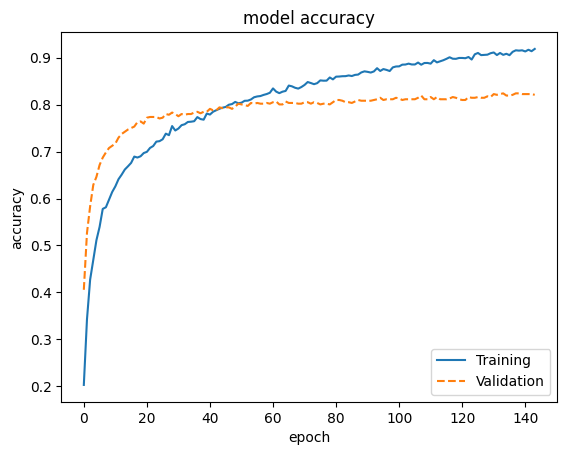

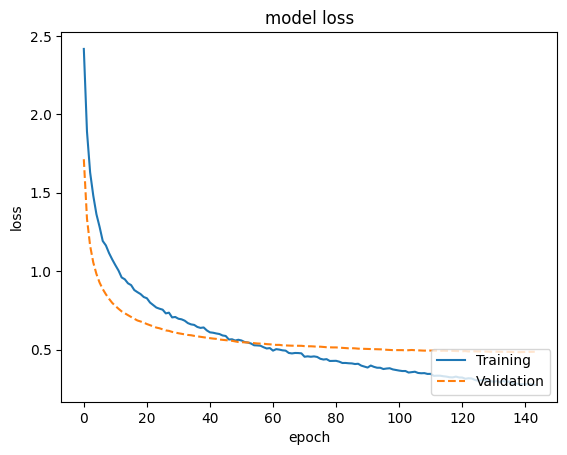

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.4843 - sparse_categorical_accuracy: 0.8208


[0.48434683680534363, 0.8207547068595886]

In [15]:
plt.plot(history_4.history['sparse_categorical_accuracy'])
plt.plot(history_4.history['val_sparse_categorical_accuracy'],linestyle='--')
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['Training', 'Validation'], loc='lower right')
plt.show()
plt.plot(history_4.history['loss'])
plt.plot(history_4.history['val_loss'],linestyle='--')
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['Training', 'Validation'], loc='lower right')
plt.show()
model_4.evaluate(test_ds)

In [ ]:
incv3_5 = keras.applications.InceptionV3(include_top=False,input_shape=(300,300,3))
incv3_5.trainable = False
for layer in incv3_5.layers[-20:]:
    layer.trainable = True
model_5 = keras.Sequential([
  layers.Input(shape=(300,300,3),name='input'),
  layers.Rescaling(1./127.5, offset=-1),
  incv3_5,
  layers.GlobalAveragePooling2D(),
  layers.BatchNormalization(),
  layers.Dense((128),activation='gelu',
                   kernel_regularizer=keras.regularizers.L1L2(l1=1e-5, l2=1e-4),
                   ),
  layers.Dropout(0.4),
  layers.Dense((NUM_CLASSES),activation = 'softmax',name='output')
])
model_5.summary()
keras.backend.clear_session(free_memory=True)
model_5.compile(
    optimizer=keras.optimizers.AdamW(learning_rate=1e-5,weight_decay=1e-4),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=[keras.metrics.SparseCategoricalAccuracy()],
)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 300, 300, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ inception_v3 (Functional)       │ (None, 8, 8, 2048)     │    21,802,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_94          │ (None, 2048)           │         8,192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,074,280 (84.21 MB)

 Trainable params: 2,202,760 (8.40 MB)

 Non-trainable params: 19,871,520 (75.80 MB)

In [17]:
history_5 = model_5.fit(train_ds,
        batch_size=BATCH_SIZE,
        epochs=EPOCHS,
          validation_data=val_ds,
        callbacks=[
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=5,
            restore_best_weights=True,
        )]        )

Epoch 1/500
233/233 ━━━━━━━━━━━━━━━━━━━━ 24s 69ms/step - loss: 2.1851 - sparse_categorical_accuracy: 0.3029 - val_loss: 1.3867 - val_sparse_categorical_accuracy: 0.5943
Epoch 2/500
233/233 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - loss: 1.4619 - sparse_categorical_accuracy: 0.5249 - val_loss: 0.9747 - val_sparse_categorical_accuracy: 0.6871
Epoch 3/500
233/233 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - loss: 1.2387 - sparse_categorical_accuracy: 0.5901 - val_loss: 0.8381 - val_sparse_categorical_accuracy: 0.7343
Epoch 4/500
233/233 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - loss: 1.0866 - sparse_categorical_accuracy: 0.6470 - val_loss: 0.7728 - val_sparse_categorical_accuracy: 0.7563
Epoch 5/500
233/233 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - loss: 0.9765 - sparse_categorical_accuracy: 0.6831 - val_loss: 0.7239 - val_sparse_categorical_accuracy: 0.7720
Epoch 6/500
233/233 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - loss: 0.9133 - sparse_categorical_accuracy: 0.7004 - val_loss: 0.6963 - val_sparse_categorical_accuracy

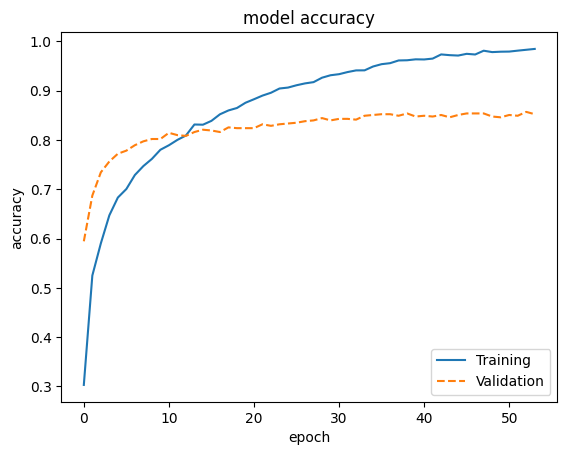

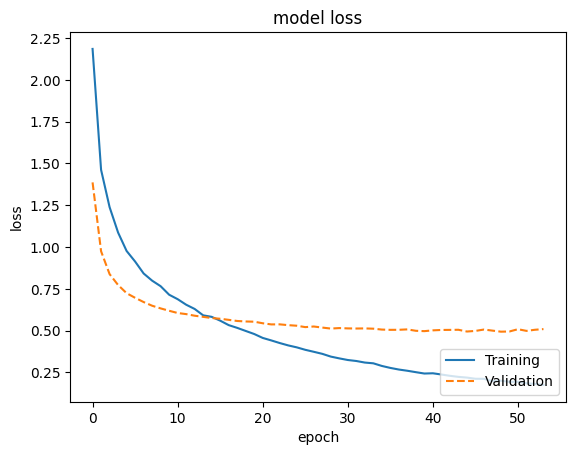

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.5262 - sparse_categorical_accuracy: 0.8538


[0.5262376070022583, 0.8537735939025879]

In [18]:
plt.plot(history_5.history['sparse_categorical_accuracy'])
plt.plot(history_5.history['val_sparse_categorical_accuracy'],linestyle='--')
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['Training', 'Validation'], loc='lower right')
plt.show()
plt.plot(history_5.history['loss'])
plt.plot(history_5.history['val_loss'],linestyle='--')
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['Training', 'Validation'], loc='lower right')
plt.show()
model_5.evaluate(test_ds)

In [19]:
model_5.save('stft_model.keras')